In [1]:
import os
import torch
import torch.nn.functional as F

def normalize_embeddings(embedding_dict, device):
    for key, embedding in embedding_dict.items():
        norm_embedding = F.normalize(embedding.unsqueeze(0), p=2, dim=1)  # Apply L2 norm
        embedding_dict[key] = norm_embedding.squeeze(0).to(device)
    return embedding_dict

def load_embeddings(embedding_string, task):
    task_directories = {
        'aav': 'aav',
        'gb1': 'gb1',
        'gfp': 'gfp',
        'location': 'location',
        'meltome': 'meltome',
        'stability': 'stability',
        'ppi': 'protein-protein',
        'cath':'cath'
    }

    if task not in task_directories:
        raise ValueError(f"Unknown task '{task}'. Available tasks are: {list(task_directories.keys())}")

    base_directory = '../embeddings'
    task_directory = os.path.join(base_directory, task_directories[task])

    embedding_map = {
        '0': os.path.join(task_directory, 'ankh/protein_dictionary.pt'),
        '1': os.path.join(task_directory, 'esm2(650M)/protein_dictionary.pt') if task =='ppi' else os.path.join(task_directory, 'esm2(3B)/protein_dictionary.pt'),
        '2': os.path.join(task_directory, 'prott5/protein_dictionary.pt'),
        
        'B': os.path.join(task_directory, 'esm3/protein_dictionary.pt'),
        'C': os.path.join(task_directory, 'ontoprotein/protein_dictionary.pt'),
        'D': os.path.join(task_directory, 'proteinclip_esm3b/protein_dictionary.pt') if task=='cath' else os.path.join(task_directory, 'proteinclip_t5/protein_dictionary.pt') ,
        'E': os.path.join(task_directory, 'protst/protein_dictionary.pt'), 
        'F': os.path.join(task_directory, 'protrek/protein_dictionary.pt'),
        'G': os.path.join(task_directory, 'proteindt/protein_dictionary.pt'),
    }

    dictionaries = []
    for char in embedding_string:
        if char in embedding_map:
            try:
                dictionary = torch.load(embedding_map[char])
                dictionaries.append(dictionary)
            except Exception as e: 
                raise ValueError(f"Failed to load embeddings for '{char}' at '{embedding_map[char]}': {str(e)}")
        else:
            raise ValueError(f"Invalid character '{char}' in embedding string. Valid keys are: {list(embedding_map.keys())}")
    return dictionaries

# Given embeddings [N], [M], [K],  return [N+M+K], concatenated in order of input
def concatenate_embeddings(dict_list):
    if not dict_list:
        raise ValueError("No embedding dictionaries provided.")

    concatenated_embedding_dict = {}
    keys = dict_list[0].keys()

    for key in keys:
        tensors_to_concat = [d[key] for d in dict_list if key in d]
        if not tensors_to_concat:
            raise ValueError(f"No embeddings found for key '{key}'.")
        concatenated_embedding_dict[key] = torch.cat(tensors_to_concat, dim=0)

    if concatenated_embedding_dict:
        one_key = next(iter(concatenated_embedding_dict))
        embedding_dim = concatenated_embedding_dict[one_key].shape[0]
    else:
        raise ValueError("No valid embeddings to concatenate.")

    return concatenated_embedding_dict, embedding_dim

In [2]:
dictionaries = load_embeddings("02BDF", "cath")
normalized_dictionaries = [normalize_embeddings(dict_emb, 'cpu') for dict_emb in dictionaries]
embedding_dictionary, _ = concatenate_embeddings(dictionaries)

/tmp/ipykernel_1969344/1233832329.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dictionary = torch.load(embedding_map[char])


/new-stg/home/young/miniconda3/envs/cuda121/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


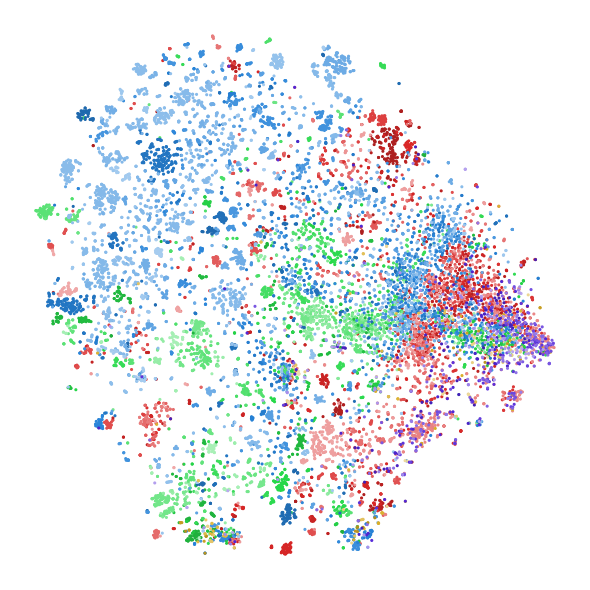

In [3]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Load TSV
df = pd.read_csv("/new-stg/home/young/Benchmarking-tpLMs/data/cath/cath_superfamilies.tsv", sep='\t', header=None, names=['protein', 'superfamily'])

# Get embeddings
embeddings = torch.stack([embedding_dictionary[pid] for pid in df['protein']])

# Optional: PCA to reduce dimensions before t-SNE (recommended if dim > 50)
pca = PCA(n_components=50)
embeddings_pca = pca.fit_transform(embeddings.numpy())

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=50, metric='cosine', n_iter=3000, random_state=42)
reduced = tsne.fit_transform(embeddings)

def get_family_group(label, level=2):
    parts = label.split('.')
    return '.'.join(parts[:level])

# Use level=2 for CA
group_labels = [get_family_group(label, level=4) for label in df['superfamily']]

import colorsys
import matplotlib.pyplot as plt

# Step 1: Define base hues for each C class
C_hues = {
    '1': 0.0,              # red
    '2': 132/360,          # greenish
    '3': 208.76/360,       # blue
    '4': 45/360,           # yellow
    '6': 254.9/360,        # purple
}

# Step 2: Extract C and full CATH
df['C'] = df['superfamily'].apply(lambda x: x.split('.')[0])
df['CATH'] = df['superfamily']

# Step 3: Assign unique CATHs a shade within each C
CATH_shades = {}
for c in df['C'].unique():
    cath_in_c = sorted(df[df['C'] == c]['CATH'].unique())
    for i, cath in enumerate(cath_in_c):
        l = 0.4 + 0.4 * (i / max(1, len(cath_in_c)-1))  # vary lightness
        s = 0.7
        h = C_hues[c]
        r, g, b = colorsys.hls_to_rgb(h, l, s)
        CATH_shades[cath] = (r, g, b)

# Step 4: Assign colors based on full CATH
colors = [CATH_shades[cath] for cath in df['CATH']]


fig, ax = plt.subplots(figsize=(6, 6))  # this replaces plt.figure()

# Scatter plot
ax.scatter(reduced[:, 0], reduced[:, 1], c=colors, s=1.5, alpha=1)

# Labels and title
ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(axis='both', which='both', length=0)  # removes tick marks
# Despine: hide top/right, show + style left/bottom
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
#plt.show()
plt.savefig("combined_cath_sf_nolines.svg")


In [19]:
dictionaries = load_embeddings("D", "cath")
normalized_dictionaries = [normalize_embeddings(dict_emb, 'cpu') for dict_emb in dictionaries]
embedding_dictionary, _ = concatenate_embeddings(dictionaries)

/new-stg/home/young/miniconda3/envs/cuda121/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


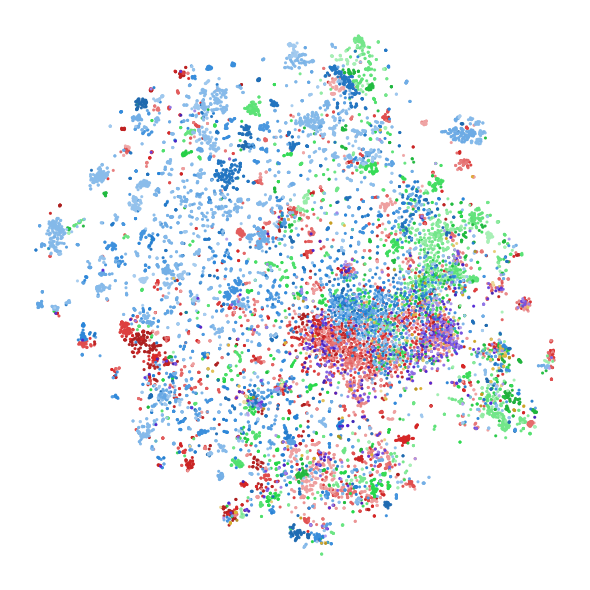

In [20]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Load TSV
df = pd.read_csv("/new-stg/home/young/Benchmarking-tpLMs/data/cath/cath_superfamilies.tsv", sep='\t', header=None, names=['protein', 'superfamily'])

# Get embeddings
embeddings = torch.stack([embedding_dictionary[pid] for pid in df['protein']])

# Optional: PCA to reduce dimensions before t-SNE (recommended if dim > 50)
pca = PCA(n_components=50)
embeddings_pca = pca.fit_transform(embeddings.numpy())

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=50, metric='cosine', n_iter=3000, random_state=42)
reduced = tsne.fit_transform(embeddings)

def get_family_group(label, level=2):
    parts = label.split('.')
    return '.'.join(parts[:level])

# Use level=2 for CA
group_labels = [get_family_group(label, level=4) for label in df['superfamily']]

import colorsys
import matplotlib.pyplot as plt

# Step 1: Define base hues for each C class
C_hues = {
    '1': 0.0,              # red
    '2': 132/360,          # greenish
    '3': 208.76/360,       # blue
    '4': 45/360,           # yellow
    '6': 254.9/360,        # purple
}

# Step 2: Extract C and full CATH
df['C'] = df['superfamily'].apply(lambda x: x.split('.')[0])
df['CATH'] = df['superfamily']

# Step 3: Assign unique CATHs a shade within each C
CATH_shades = {}
for c in df['C'].unique():
    cath_in_c = sorted(df[df['C'] == c]['CATH'].unique())
    for i, cath in enumerate(cath_in_c):
        l = 0.4 + 0.4 * (i / max(1, len(cath_in_c)-1))  # vary lightness
        s = 0.7
        h = C_hues[c]
        r, g, b = colorsys.hls_to_rgb(h, l, s)
        CATH_shades[cath] = (r, g, b)

# Step 4: Assign colors based on full CATH
colors = [CATH_shades[cath] for cath in df['CATH']]


fig, ax = plt.subplots(figsize=(6, 6))  # this replaces plt.figure()

# Scatter plot
ax.scatter(reduced[:, 0], reduced[:, 1], c=colors, s=1.5, alpha=0.9)

# Labels and title
ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(axis='both', which='both', length=0)  # removes tick marks
# Despine: hide top/right, show + style left/bottom
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
#plt.show()
plt.savefig("pclip_cath_sf_nolines.svg")
